<a href="https://colab.research.google.com/github/hieuvu-0111/Deep-Learning-with-AlexNet-and-CIFAR-10/blob/main/Deep_Learning_CNN_architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN architectures {-}

This notebook is adapted from a Deep Learning course assignment. It involves training and testing the a CNN for an image classification task. We will go through the process of loading data, preprocessing images, building the CNN model, evaluating its performance, and discussing some relevant questions. Particularly,

1.  **Coding tasks:**

    1.1 Implement a CNN architecture selected from the TensorFlow Keras Applications library (from the provided list https://www.tensorflow.org/api_docs/python/tf/keras/applications, excluding VGG16 and VGG19).  

    1.2 Train the selected CNN and evaluate its performance on the image classification task using appropriate evaluation metrics.  
    
    1.3 Enhance the model by introducing architectural modifications such as skip connections or by tuning layer level hyperparameters to improve performance.  

    1.4 Train and evaluate the enhanced model on the test dataset.

    1.5 Provide analysis and observations explaining how the applied modifications affected the model’s performance and behavior.  

2.  **Open discussion questions:**

    2.1 When choosing a CNN architecture from the TensorFlow Keras library, what factors should be considered, such as model depth, number of parameters, and expected performance on the given dataset, and why might some architectures be more suitable than others for this specific image classification task?  

    2.2 During the data loading and preprocessing stage, in your opinion, what types of preprocessing steps are most important for image classification tasks, and how can improper preprocessing negatively affect the training stability and final performance of a CNN model?  

    2.3 After training the selected CNN model, how should different evaluation metrics such as accuracy, precision, recall, or confusion matrix be interpreted together to obtain a more complete understanding of the model’s strengths and weaknesses?  

    2.4 When introducing architectural modifications such as skip connections, what problems in deep neural networks are these modifications designed to solve, and how do they conceptually change the way information flows through the model?  

    2.5 From a broader perspective, what lessons can be learned from this assignment about the iterative nature of deep learning model development? Discuss why building an effective model typically requires repeated cycles of data preparation, model design, training, evaluation, and refinement rather than a single linear process.  

The dataset we will be working on is The CIFAR-10. This dataset consists of 60,000 32x32 colour images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

In [ ]:
# Note: to enable GPU training in Colab, go to Runtime > Change runtime type > Hardware acceleration > Choose GPU from the drop-down list.

!pip install tensorflow_datasets

# Import libraries
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10
from keras.layers import Dropout, Flatten, Dense, BatchNormalization
from keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [ ]:
# PLEASE DO NOT CHANGE THIS CODE

# Get the full dataset (batch_size=-1) in NumPy arrays from the returned tf.Tensor object
cifar10_train = tfds.load(name="cifar10", split=tfds.Split.TRAIN, batch_size=-1 )
cifar10_test = tfds.load(name="cifar10", split=tfds.Split.TEST, batch_size=-1)

# Convert tfds dataset to numpy array records
cifar10_train = tfds.as_numpy(cifar10_train)
cifar10_test = tfds.as_numpy(cifar10_test)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.396SJH_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.396SJH_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


# Data processing and model training

In [ ]:
# Seperate feature X and label Y
X_train, Y_train = cifar10_train["image"], cifar10_train["label"]
X_test, Y_test = cifar10_test["image"], cifar10_test["label"]
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, random_state=99, test_size=0.2)

# Normalize the image data
X_train = X_train/255
X_val = X_val/255
X_test = X_test/255

# Specify the input image size and number of classes
img_width, img_height = 32, 32
nb_classes = 10

# Converts a class vector (integers) to binary class matrix to have one-hot encoding label. For example:
Y_train = keras.utils.to_categorical(Y_train, nb_classes)
Y_val = keras.utils.to_categorical(Y_val, nb_classes)
Y_test = keras.utils.to_categorical(Y_test, nb_classes)

## 1. Coding tasks

### 1.1 (1 point) Implement a CNN architecture selected from the TensorFlow Keras Applications library (from the provided list https://www.tensorflow.org/api_docs/python/tf/keras/applications, excluding VGG16 and VGG19).


In [ ]:
# Initialize the model Resnet50 from tf.keras.applications
model_resnet50 = tf.keras.applications.ResNet50(
    include_top=False,             # Whether to include the 3 fully-connected layers at the top of the network.
    weights='imagenet',           # None for random initialization, or 'imagenet' for using pre-training on ImageNet.
    input_shape=(img_width, img_height, 3),             # Specify input input_shape
    pooling=None,
    classifier_activation='softmax' # This parameter is ignored because include_top is set to False
)

In [ ]:
# Print the shape of sets
print("Training set shape: " + str(X_train.shape))
print("validation set shape: " + str(X_val.shape))
print("Test set shape: " + str(X_test.shape))

Training set shape: (40000, 32, 32, 3)
validation set shape: (10000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


In [ ]:
# Print model summary
model_resnet50.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# Take the output of the model ResNet50
x = model_resnet50.output

# Freeze the base model layers to preserve pre-trained weights.
# This prevents the ResNet50 weights from being updated during the first stage of training.
model_resnet50.trainable = False

# Add classification layers on top of it.
x = GlobalAveragePooling2D()(x)
pred = Dense(nb_classes, activation='softmax')(x)

# Define a new model by grouping layers into an object with training and inference features.
model_resnet50_cifar10 = Model(inputs=model_resnet50.input, outputs=pred)

In [ ]:
# Print model summary. See the changes in the model structure and the number of trainable parameters.
model_resnet50_cifar10.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 1.2 (1 point) Train the selected CNN and evaluate its performance on the image classification task using appropriate evaluation metrics.


In [ ]:
# Compile the model with Adam optimizer and a learning rate.
model_resnet50_cifar10.compile(loss='categorical_crossentropy', # Categorical cross-entropy as loss function
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Optimizer of Gradient descent (with momentum) as optimizer.
              metrics=['accuracy']) # Metric to evaludate the model performance

In [ ]:
# Train the model
model_training = model_resnet50_cifar10.fit(X_train, Y_train,
                                          batch_size=256,
                                          epochs=30,
                                          validation_data=(X_val, Y_val),
                                          shuffle=True)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 98ms/step - accuracy: 0.1735 - loss: 2.2761 - val_accuracy: 0.2247 - val_loss: 2.1237
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.2487 - loss: 2.0804 - val_accuracy: 0.2760 - val_loss: 2.0305
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.2835 - loss: 2.0029 - val_accuracy: 0.2987 - val_loss: 1.9764
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.3047 - loss: 1.9589 - val_accuracy: 0.3116 - val_loss: 1.9370
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3158 - loss: 1.9247 - val_accuracy: 0.3172 - val_loss: 1.9253
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3223 - loss: 1.9051 - val_accuracy: 0.3353 - val_loss: 1.8859
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.3335 - loss: 1.8829 - val_accuracy: 0.3158 - val_loss: 1.9081
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.3397 - loss: 1.8671 - val_acc

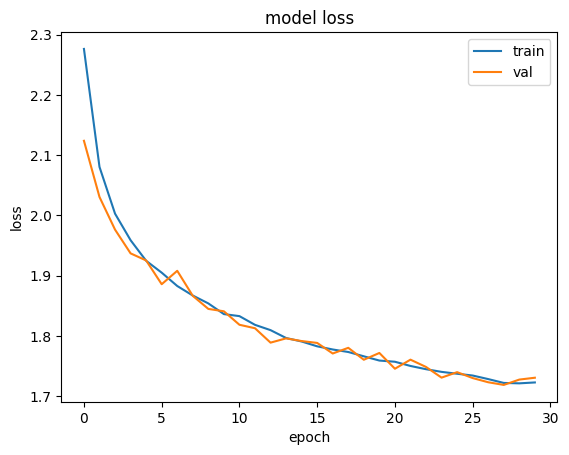

In [ ]:
# Visualize the training and validation loss over epochs
plt.plot(model_training.history['loss'])
plt.plot(model_training.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

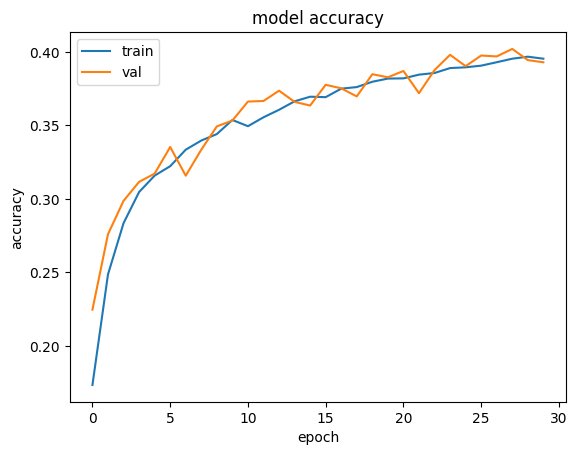

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(model_training.history['accuracy'])
plt.plot(model_training.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Evaluate the model prediction on a data sample
pred = model_resnet50_cifar10.predict(X_test[:1]) # Make prediction on a data sample
print("Model prediction: " + str(pred)) # Model prediction
print("True label: " + str(Y_test[:1])) # True label

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Model prediction: [[0.13362089 0.01487552 0.14713413 0.10083167 0.16934848 0.06461606
  0.01487133 0.254046   0.08588529 0.01477073]]
True label: [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [ ]:
# Evaluate the model prediction on the entire test set
preds = model_resnet50_cifar10.predict(X_test) # Make prediction on the entire test set
preds_index = np.argmax(preds, axis=1) # Get the index of maximum class probability of each of the data sample
label_index = np.argmax(Y_test, axis=1) # Get the index of maximum class label

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step


In [ ]:
# Compare the predictions with the true labels
comparison_result = np.equal(preds_index, label_index) # Return the comparison result which is an array of True/False.

# Calculate the number of correct predictions (True values in the comparison result array).
correct_preds = comparison_result.sum() # Compute the sum of elements across dimensions of a tensor.

# Show accuracy
print("Number of correct predictions: " + str(correct_preds))
print("Test accuracy: " + str(correct_preds/X_test.shape[0]))

Number of correct predictions: 3915
Test accuracy: 0.3915


In [ ]:
# Evaluate the model accuracy using the function model.evaluate()
model_eval = model_resnet50_cifar10.evaluate(X_test, Y_test, batch_size=4096)
print("List of metrics" + str(model_resnet50_cifar10.metrics_names)) # List of possible metrics of the model evaluation, this is the metrics specified in the model.compile().

print("Test loss: " + str(model_eval[0])) # Test loss
print("Test accuracy: " + str(model_eval[1])) # Test accuracy

3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.3915 - loss: 1.7352
List of metrics['loss', 'compile_metrics']
Test loss: 1.735219955444336
Test accuracy: 0.39149999618530273


As we may see, these are some metrics about performance of our original ResNet50:
*   Test Accuracy: ~39.15%
*   Test Loss: ~1.74

Also, looking at the graphs above, we notice that training and validation loss curves show a gradual decrease (which is good), the model accuracy fluctuates yet generally increases. The difference between training accuracy and validation accuracy is generally small, so we can tell that the model is not overfitted.  The test accuracy of 39.15%, while better than random guess, it's very low for a ResNet50 model and for the CIFAR-10 dataset. From that, we can conclude that the model is underfitted.

**What might be the causes of poor perfomance in our model?**

First, perhaps the original Resnet model is not appropriate with CIFAR-10 dataset. Indeed, ResNet50 was originally designed for much larger images (e.g., 224x224 pixels) from ImageNet. When fed 32x32 CIFAR-10 images directly, its convolutional and pooling layers quickly downsample the image, thus it leads to a tremendous loss of spatial information. By the time features reach the classification head, they are too abstract and lack the detail necessary to distinguish between CIFAR-10 classes, causing underfitting.

Second, we have chosen to freeze the entire ResNet50 backbone. It means that the pre-trained ImageNet weights are not updated during training process. Although this can prevent the loss of foundational features, it does not give our model a chance to learn from particular CIFAR-10 dataset. Those foundational features were optimized for ImageNet's high-resolution images, so they may not perfectly capture the specific textures and small-scale patterns in our CIFAR-10 dataset. As the result, it limits the model's accuracy.

**Potential Enhancement Strategy**

We raise some following adjustments aiming to solve the issue descibed above about underfitting:

1.  **Upsampling input**: Scaling up the 32x32 CIFAR-10 images to a larger resolution (e.g., 128x128) before feeding them to the ResNet50 backbone. This allows the deeper layers of ResNet50 to operate on more meaningful spatial information.

2.  **Adding skip connections**: Instead of just using the final output of the ResNet50 backbone, we insert skip connections that bridge earlier layers of the ResNet50 to the classification head. This allows the model to fuse low-level spatial details with high-level semantic information, ensuring that small features, which are important for identifying small objects in CIFAR-10, are preserved throughout the training process.

3.  **Modify classification layers**: Designing a more robust classification head with additional dense layers, batch normalization, and dropout to better learn from the extracted features and reduce overfitting (we suppose that model will be overfitted instead of underfitted when applying all adjustments).

4.  **Two-phase Training**: This one is the center of our modification. We implement a warm-up phase where only the new classification head is trained (with the ResNet backbone frozen), followed by a fine-tuning phase where the entire network (including the ResNet50 backbone) is unfrozen and trained with a very low learning rate. This adapts the pre-trained weights to the CIFAR-10 specifics while preserving the learned ImageNet features at the same time.

### 1.3 (1 point) Enhance the model by introducing architectural modifications such as skip connections or by tuning layer level hyperparameters to improve performance.

We now apply the adjustments introduced above to train the second model.

In [ ]:
from tensorflow.keras import layers, models, applications, regularizers

# Define the resnet backbone (similar to the 1st model)
base_resnet_model = applications.ResNet50(
    include_top=False, # We will add our own top layers
    weights='imagenet',
    input_shape=(128, 128, 3) # Input shape for the base model after upsampling
)

# Freeze the entire base model for phase 1
# This ensures that during the feature extracting process,
# the base_resnet_model's trainable state is correctly set.
for layer in base_resnet_model.layers:
    layer.trainable = False

# Build the enhanced model architecture
def build_enhanced_model(base_resnet_model):
    inputs = layers.Input(shape=(32, 32, 3)) # Original CIFAR-10 size

    # Data augumentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # Upsampling to match resnet original resolution (128x128)
    x = layers.UpSampling2D(size=(4, 4))(x)

    # Create a sub-model (feature_extractor) from the base_resnet_model to output the desired intermediate layers.
    feature_extractor = models.Model(
        inputs=base_resnet_model.input,
        outputs=[
            base_resnet_model.get_layer('conv4_block6_out').output, # Main branch output (stage 4)
            base_resnet_model.get_layer('conv2_block3_out').output  # Skip connection output (stage 2)
        ],
        name="resnet50_feature_extractor"
    )

    # Pass the upsampled input through the feature extractor
    main_features_out, skip_features_out = feature_extractor(x)

    # Process the main branch output
    main_pooled = layers.GlobalAveragePooling2D()(main_features_out)

    # Process the skip connection output
    skip_pooled = layers.GlobalAveragePooling2D()(skip_features_out)

    # Concatenate the pooled features
    concatenated_features = layers.concatenate([main_pooled, skip_pooled])

    # Add classification layers to top of it
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(concatenated_features)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model_enhanced = build_enhanced_model(base_resnet_model)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Print model summary. See the changes in the model structure and the number of trainable parameters.
model_enhanced.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 32, 32, 3) │          0 │ input_layer_1[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 32, 32, 3) │          0 │ random_flip[0][0] │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 32, 32, 3) │          0 │ random_rotation[… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ random_zoom[0][0] │
│ (UpSampling2D)      │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50_feature_e… │ [(None, 8, 8,     │  8,589,184 │ up_sampling2d[0]… │
│ (Functional)        │ 1024), (None, 32, │            │                   │
│                     │ 32, 256)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ resnet50_feature… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ resnet50_feature… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1280)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │      2,570 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,382,026 (35.79 MB)

 Trainable params: 791,306 (3.02 MB)

 Non-trainable params: 8,590,720 (32.77 MB)

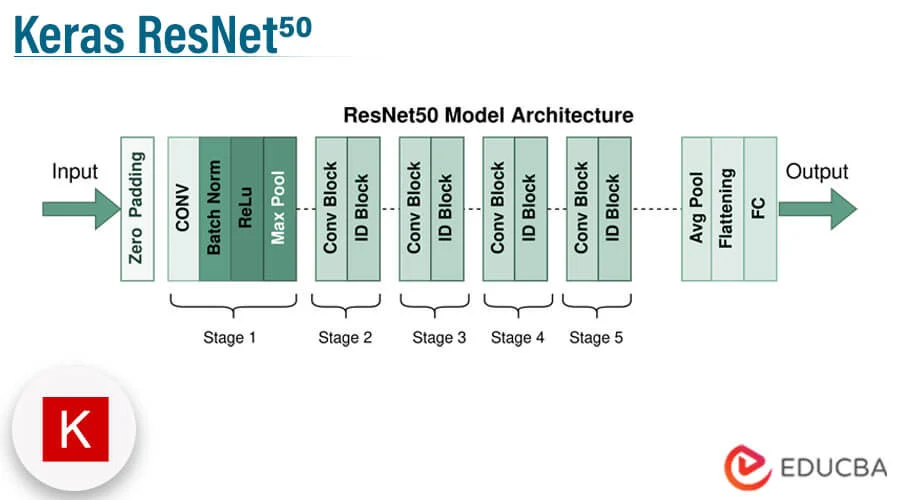

Most of the adjustments are described earler in the analysis of initial model's result. Here we elaborate more on the choice of skip connections, data augmentation and classification head and two phase strategy.

1.  **Skip connections from intermediate layers**: Instead of solely relying on the final output of the ResNet50 backbone, we use skip connection by `GlobalAveragePooling2D`and concatenating features from an earlier stage of the ResNet50. Particularly, features were extracted from:
    *   `conv4_block6_out` (output of Stage 4): This provides higher-level, more abstract semantic features.
    *   `conv2_block3_out` (output of Stage 2): This provides lower-level, finer-grained features. For small images like CIFAR-10, small details are important for classification and might be lost in deeper layers.

2.  **Classification Head**: A more robust classification head was designed, including:
    *   Two Dense layers with ReLU activation, each followed by `BatchNormalization` and `Dropout`. Batch Normalization helps stabilize training process, and Dropout drops random connections in order to prevent overfitting.
    *   L2 regularization was added to the dense layers to avoid overfitting by penalizing large weights.

3.  **Data augmentation**: We use basic data augmentation techniques. This helps increase the diversity of the training data, making the model more robust to variations in the input images and reducing overfitting (if any).

4.  **Two-phase training**:
    *   **Phase 1 (training the head)**: Initially, the entire `base_resnet_model` was frozen, and only the newly added custom classification head was trained for only 10 epochs with a higher learning rate (compared to 2nd phase later). This makes the classification head to quickly learn to interpret the features provided by the pre-trained Resnet without changing the weights.
    *   **Phase 2 (Fine-tuning for the whole network)**: Then, the `base_resnet_model` was unfrozen. The entire `model_enhanced` was then recompiled with a lower learning rate and trained for 30 epochs. This allows the pre-trained weights of ResNet50 to be subtly adjusted and adapted to the specific information in the CIFAR10 dataset, while still preserving the general feature extraction capabilities from ImageNet.

### 1.4 (1 point) Train and evaluate the enhanced model on the test dataset.


In [ ]:
# Training phase 1 (head)
from keras.callbacks import ModelCheckpoint
import os

# Define checkpoint directory and filename format for Phase 1
checkpoint_dir_phase1 = 'checkpoints_phase1'
os.makedirs(checkpoint_dir_phase1, exist_ok=True)
checkpoint_filepath_phase1 = os.path.join(checkpoint_dir_phase1, 'model_phase1_epoch_{epoch:02d}_val_acc_{val_accuracy:.4f}.weights.h5')

# Create a ModelCheckpoint callback for Phase 1
model_checkpoint_callback_phase1 = ModelCheckpoint(
    filepath=checkpoint_filepath_phase1,
    monitor='val_accuracy', # Monitor validation accuracy
    save_best_only=False,   # We want to save all epochs for phase 1 or the last one
    save_weights_only=True, # Only save the weights, not the entire model
    mode='max',            # Maximize val_accuracy
    verbose=1
)

# Find the latest checkpoint for Phase 1 if it exists to resume training
latest_epoch_phase1 = 0
if os.path.exists(checkpoint_dir_phase1):
    checkpoints_phase1 = [f for f in os.listdir(checkpoint_dir_phase1) if f.endswith('.weights.h5')]
    if checkpoints_phase1:
        # Sort checkpoints by epoch number to find the latest one
        checkpoints_phase1.sort(key=lambda x: int(x.split('_')[2].split('d')[0]))
        latest_checkpoint_phase1 = os.path.join(checkpoint_dir_phase1, checkpoints_phase1[-1])
        print(f"Loading weights for Phase 1 from latest checkpoint: {latest_checkpoint_phase1}")
        model_enhanced.load_weights(latest_checkpoint_phase1)
        latest_epoch_phase1 = int(checkpoints_phase1[-1].split('_')[2].split('d')[0])
        print(f"Resuming Phase 1 training from epoch {latest_epoch_phase1 + 1}")

model_enhanced.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # use smaller learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_enhanced_training = model_enhanced.fit(X_train, Y_train,
                                          batch_size=256,
                                          epochs=10,
                                          validation_data=(X_val, Y_val),
                                          callbacks=[model_checkpoint_callback_phase1], # Add checkpoint callback for Phase 1
                                          initial_epoch=latest_epoch_phase1
                                         )

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.2347 - loss: 3.2996
Epoch 1: saving model to checkpoints_phase1/model_phase1_epoch_01_val_acc_0.1043.weights.h5

Epoch 1: finished saving model to checkpoints_phase1/model_phase1_epoch_01_val_acc_0.1043.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 360ms/step - accuracy: 0.2699 - loss: 2.9150 - val_accuracy: 0.1043 - val_loss: 9.5004
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.3376 - loss: 2.4160
Epoch 2: saving model to checkpoints_phase1/model_phase1_epoch_02_val_acc_0.1099.weights.h5

Epoch 2: finished saving model to checkpoints_phase1/model_phase1_epoch_02_val_acc_0.1099.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - accuracy: 0.3509 - loss: 2.3288 - val_accuracy: 0.1099 - val_loss: 7.5792
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.3744 - loss: 2.1465
Epoch 3: saving model to checkpoints_phase1/model_phase1_epoch_03_val_acc_0.1052.weights.h5

Epoch 3: finish

In [ ]:
# Training phase 2 with fine-tuning

from keras.callbacks import ModelCheckpoint, EarlyStopping
import os

# Define checkpoint directory and filename format
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_filepath = os.path.join(checkpoint_dir, 'model_epoch_{epoch:02d}_val_acc_{val_accuracy:.4f}.weights.h5')

# Create a ModelCheckpoint callback
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy', # Monitor validation accuracy
    save_best_only=True,   # Save only the best model weights
    save_weights_only=True, # Only save the weights, not the entire model
    mode='max',            # Maximize val_accuracy
    verbose=1
)

# Create an EarlyStopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',     # Monitor validation loss
    patience=5,             # Stop after 5 epochs of no improvement
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# Find the latest checkpoint if it exists to resume training
latest_epoch = 0
if os.path.exists(checkpoint_dir):
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.endswith('.weights.h5')]
    if checkpoints:
        # Sort checkpoints by epoch number to find the latest one
        checkpoints.sort(key=lambda x: int(x.split('_')[1].split('d')[0]))
        latest_checkpoint = os.path.join(checkpoint_dir, checkpoints[-1])
        print(f"Loading weights from latest checkpoint: {latest_checkpoint}")
        model_enhanced.load_weights(latest_checkpoint)
        latest_epoch = int(checkpoints[-1].split('_')[1].split('d')[0])
        print(f"Resuming training from epoch {latest_epoch + 1}")

# Unfreeze the base_resnet_model to adapt to CIFAR textures
for layer in base_resnet_model.layers:
    layer.trainable = True

# Recompile the model
model_enhanced.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_enhanced_training = model_enhanced.fit(X_train, Y_train,
                                          batch_size=256,
                                          epochs=30,
                                          validation_data=(X_val, Y_val),
                                          shuffle=True,
                                          callbacks=[model_checkpoint_callback, early_stopping_callback], # Add both checkpoint and early stopping callbacks
                                          initial_epoch=latest_epoch # Start training from the epoch after the last loaded checkpoint
                                         )

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3420 - loss: 2.0663
Epoch 1: val_accuracy improved from None to 0.10430, saving model to checkpoints/model_epoch_01_val_acc_0.1043.weights.h5

Epoch 1: finished saving model to checkpoints/model_epoch_01_val_acc_0.1043.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.4133 - loss: 1.8091 - val_accuracy: 0.1043 - val_loss: 8.8905
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5544 - loss: 1.3827
Epoch 2: val_accuracy did not improve from 0.10430
157/157 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.5855 - loss: 1.3140 - val_accuracy: 0.1043 - val_loss: 6.7523
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6521 - loss: 1.1635
Epoch 3: val_accuracy improved from 0.10430 to 0.10460, saving model to checkpoints/model_epoch_03_val_acc_0.1046.weights.h5

Epoch 3: finished saving model to checkpoints/model_epoch_03_val_acc_0.1046.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 213s 1

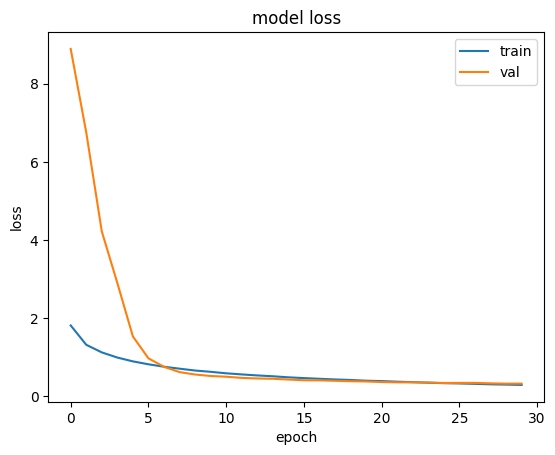

In [ ]:
# Visualize the training and validation loss over epochs
plt.plot(model_enhanced_training.history['loss'])
plt.plot(model_enhanced_training.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

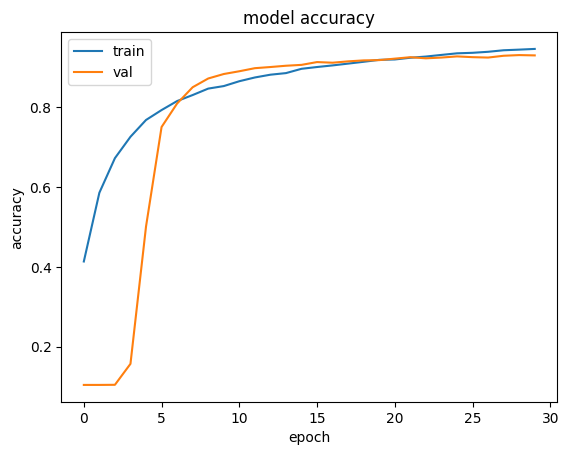

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(model_enhanced_training.history['accuracy'])
plt.plot(model_enhanced_training.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Evaluate the model prediction on a data sample
pred = model_enhanced.predict(X_test[:1]) # Make prediction on a data sample
print("Model prediction: " + str(pred)) # Model prediction
print("True label: " + str(Y_test[:1])) # True label

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Model prediction: [[1.3859021e-03 2.6187210e-04 2.3978290e-03 1.2331075e-03 4.9879742e-03
  8.2451114e-03 5.4928998e-04 9.7927094e-01 8.3434432e-05 1.5846852e-03]]
True label: [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [ ]:
# Evaluate the model prediction on the entire test set
preds = model_enhanced.predict(X_test) # Make prediction on the entire test set
preds_index = np.argmax(preds, axis=1) # Get the index of maximum class probability of each of the data sample
label_index = np.argmax(Y_test, axis=1) # Get the index of maximum class label

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step


In [ ]:
# Evaluate the model accuracy using the function model.evaluate()
model_eval = model_enhanced.evaluate(X_test, Y_test, batch_size=256)
print("List of metrics" + str(model_enhanced.metrics_names)) # List of possible metrics of the model evaluation, this is the metrics specified in the model.compile().

print("Test loss: " + str(model_eval[0])) # Test loss
print("Test accuracy: " + str(model_eval[1])) # Test accuracy

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 298ms/step - accuracy: 0.9257 - loss: 0.3321
List of metrics['loss', 'compile_metrics']
Test loss: 0.33206796646118164
Test accuracy: 0.9257000088691711


**Evaluation of Model Performance**

The enhanced model demonstrates significantly improved performance compared to the initial model. The test accuracy reached approximately **92.57%**, while the test loss decreased to about **0.332**. This is a significant improvement over the initial model's accuracy of ~39.15% with the test loss of ~1.74.

Looking at the graph of this model, we see the training and validation loss curves have a sharp decrease, thus indicating that model had an effective learning progress. The validation loss remains close to the training loss, which shows a good generalization and that the model is not overfitting. Also, the training and validation accuracy curves both show a strong upward trend. The differences between these two metrics are usually less than 1%, further indicates that the model is generalizing well to unseen data and is not overfitting.

## 2. Open discussion questions

### 2.1 (1 point) When choosing a CNN architecture from the TensorFlow Keras library, what factors should be considered, such as model depth, number of parameters, and expected performance on the given dataset, and why might some architectures be more suitable than others for this specific image classification task?


When choosing a CNN architecture from the TensorFlow Keras library, we may need to consider some following factors:

1.  **Model depth and complexity**: Deeper networks (e.g., ResNet, Inception, EfficientNet) can learn more abstract and hierarchical features, which is beneficial for complex tasks and large datasets. However, they are easier to appear issues like vanishing gradients, and require more computational resources. For simpler tasks or smaller datasets, an moderately deep model might overfit or take too long to train without significant performance gains.

2.  **Number of parameters**: The number of parameters directly correlates with the model's capacity and memory. Models with many parameters (e.g., ResNet50) require substantial data to avoid overfitting and take longer running time. Conversely, models with fewer parameters (e.g., MobileNet, EfficientNet) are more lightweight, faster, and more suitalbe for devices with humble resources. Surely the tradeoff of this choice is lower accuracy on highly complex tasks. We can use the `summary()` method to investigate the depth and parameter of a model. An example is shown below.

3.  **Expected performance on pre-trained dataset**: Many architectures come with pre-trained weights on large datasets like ImageNet. Leveraging these weights through transfer learning is often effective, especially when given dataset is small or similar to ImageNet. The expected performance of a pre-trained model on a new task depends on how dataset in our task is similar to the original training data. If the data is very different, we might need to adjust more (fine-tuning).

5.  **Dataset characteristics**: This is another important aspect. For the CIFAR-10 dataset which consists of 32x32 pixel images, architectures designed for larger images (e.g., 224x224 for ImageNet) like ResNet50 might rapidly downsample the small CIFAR-10 images in their initial layers, leading to significant loss of spatial information. This was a key issue with the baseline ResNet50 model in this assignment. For such small images, either input upsampling is necessary, or an architecture specifically designed to handle lower resolutions better would be more suitable. Also, CIFAR-10's classes are distinct (it does not mean they are trivial), so too complex models might overfit without suitable regularization or data augmentation.

Based on the analysis, for CIFAR-10, we assume that models like MobileNetV2 or EfficientNet might be more suitable. However, we deliberately chose to use ResNet50, since it is classic model for image classification, and more importantly, to really see how true our analysis is. Then, we could apply various enhancement strategies (as shown in coding part) to enhance the model, and indeed, the model is way better.

In [ ]:
# Checking parameters of MobileNetV2
from tensorflow.keras.applications import MobileNetV2

# Initialize MobileNetV2
mobilenet_base = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
mobilenet_base.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

**Comparison of ResNet50 and MobileNetV2**

MobileNetV2 has significantly fewer parameters (2.26 million) compared to ResNet50 (23.59 million). This means MobileNetV2 is
a much lighter model. For datasets like CIFAR-10, which are relatively small (50,000 training images) and feature low-resolution images (32x32), a model with fewer parameters like MobileNetV2 might be less prone to overfitting and require less computational resources for training and inference.

About the depth, ResNet50, despite having '50' in its name (referring to key convolutional layers), is a very deep and complex architecture. MobileNetV2 achieves high performance with a more efficient design, particularly through the use of depthwise separable convolutions and inverted residual blocks.

Therefore, with its much lower parameter count and efficient design, might be a more 'naturally' suitable and computationally less demanding choice for a dataset like CIFAR-10. However, as metioned above, we intentionally chose ResNet50 to verify our assumption and to see how well modifications can enhance the model.

### 2.2 (1 point) During the data loading and preprocessing stage, in your opinion, what types of preprocessing steps are most important for image classification tasks, and how can improper preprocessing negatively affect the training stability and final performance of a CNN model?


During the data loading and preprocessing stage, some following steps are crucial for the stability and performance of a CNN model:

1.  Image scaling: Images are typically composed of pixel values ranging from 0 to 255. Most deep learning models perform better when input features are on a similar scale. Using larger pixel values can lead to larger gradients, which may cause instability in the training process (e.g., exploding gradients). Normalization ensures that all features contribute equally to the loss function and helps optimization algorithms converge more efficiently.

2.  Image resizing: we use it to ensure all images have a consistent input size, especially when using pre-trained models like ImageNet with 224x224. If we use those model for datasets like CIFAR-10 which have input size of 32x32, it is important to upsampling the input size. Inconsistent image sizes would be incompatible with the model architecture. For transfer learning, resizing to the expected input dimensions of the pre-trained backbone is important for leveraging its learned features effectively. Improper resizing (e.g., downsampling too aggressively for small objects like CIFAR10) can lead to significant loss of detail.

3.  One-hot encoding of labels: It refer to converting categorical labels into a binary vector format. This is important basically because this is a requirement for training with categorical cross-entropy loss. Without one-hot encoding, the model might incorrectly infer an ordinal relationship between class labels, and the loss function would not be correctly calculated.

4.  Data augmentation: Applying random transformations (e.g., rotations, flips, zooms, shifts) to the training images to increase the diversity of the training data. It helps to prevent overfitting, especially with limited datasets. By presenting slightly varied versions of the same image, the model learns to be more robust and generalize better to unseen data. Without it, models might memorize training examples rather than learning generalized features, which lead to overfitting.

**How improper preprocessing negatively affects training stability and final performance:**

*   Unstable training without normalization: large pixel values can lead to exploding gradients or very slow convergence, making the optimization process difficult and longer. The model might fail to learn meaningful features.
*   Loss of information: Aggressive or incorrect resizing (e.g., downsampling small images like CIFAR10 dataset) can lead to loss of crucial spatial details or introduce artifacts. Also, for pre-trained models like ResNet in ImageNet, not resizing to their expected input can lead to a complete breakdown of feature extraction.
*   Incorrect label encoding: If labels are not one-hot encoded for categorical cross-entropy, the loss calculation will be incorrect, and the model will learn to predict incorrect relationships between classes, thus leading to poor accuracy.

*   Overfitting/Underfitting: Insufficient data augmentation can lead to severe overfitting, i.e., the model performs well on training data but poorly on unseen data. On the flip size, over-aggressive augmentation or incorrect normalization might distort the original data distribution too much, making it harder for the model to learn, leading to underfitting or slower learning.

*   Computational inefficiency: Processing unnormalized or inconsistently sized images can increase memory consumption and slow down training process (which then lead to out of running time if using Colab free version).

### 2.3 (1 point) After training the selected CNN model, how should different evaluation metrics such as accuracy, precision, recall, or confusion matrix be interpreted together to obtain a more complete understanding of the model’s strengths and weaknesses?


Interpreting different evaluation metrics together is important for obtaining a complete understanding of a model's strengths and weaknesses, as each metric provides a different perspective on performance.

First, for accuracy - the proportion of correctly classified instances out of the total instances, it gives a general idea of how well the model performs overall. A high accuracy usually means the model is doing well across most classes. However, it can be misleading in imbalanced datasets. For example, if 90% of the data belongs to one class, a model that always predicts that class will have 90% accuracy, but it's useless for the other 10% of classes. Therefore, accuracy alone is insufficient.

Precision is the proportion of true positive predictions among all positive predictions made by the model. It answers the question: "Of all the instances predicted as positive for a certain class, how many actually belong to that class?" High precision for a class indicates a low rate of false positives for that class. It's important when the cost of a false positive is high (e.g., labelling a non-diseased person as diseased). Then, recall is the proportion of true positive predictions among all actual positive instances. It answers the question: "Of all the instances that actually belong to a certain class, how many did the model correctly identify?" High recall for a class indicates a low rate of false negatives for that class. It's important when the cost of a false negative is high (e.g., missing a cancer patient). Also together, we have F1-score: `2 * (Precision * Recall) / (Precision + Recall)`. It provides a single metric that balances precision and recall. It's particularly useful when we need to seek a balance between precision and recall and when dealing with uneven class distribution.

Moreover, we have confusion matrix, a table that summarizes the performance of a classification model. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. It explicitly shows True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) for each class. Then we can see which classes are most often confused with each other. For example, if a model frequently misclassifies 'cat' as 'dog', the confusion matrix will show high numbers in the 'actual cat, predicted dog' cell. Then. from the confusion matrix, we can easily calculate precision, recall, and F1-score for each individual class, not just overall averages.

If we use these metrics together, it is useful to begin with confusion matrix to have an overview of model performance on each class. Then if we care more on specific class, we can calculate and review precision and recall for that class. This is when we can identify specific strengths and weaknesses. After understanding the per-class performance, we may look at the overall accuracy. If accuracy is high but some classes have very low recall or precision, it suggests a class imbalance where the model performs well on dominant classes but poorly on minority ones. Conversely, if overall accuracy is low, the per-class metrics will help pinpoint exactly which classes are causing the most trouble.
Below we do an analysis on confusion metrics of the base Resnet model (first version) and demonstrate how they together help us diagnose the problem of the model better.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
--- Evaluation Metrics for First Model ---

Overall Accuracy: 0.3915

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.54      0.34      0.41      1000
  automobile       0.48      0.35      0.40      1000
        bird       0.33      0.31      0.32      1000
         cat       0.25      0.35      0.29      1000
        deer       0.39      0.33      0.36      1000
         dog       0.52      0.20      0.29      1000
        frog       0.55      0.23      0.33      1000
       horse       0.35      0.58      0.43      1000
        ship       0.40      0.63      0.49      1000
       truck       0.42      0.59      0.49      1000

    accuracy                           0.39     10000
   macro avg       0.42      0.39      0.38     10000
weighted avg       0.42      0.39      0.38     10000


--- Confusion Matrix ---
[[335  42 125  45  32   3  14  68 282  54]
 [ 39 346   5  49  13   3  19  

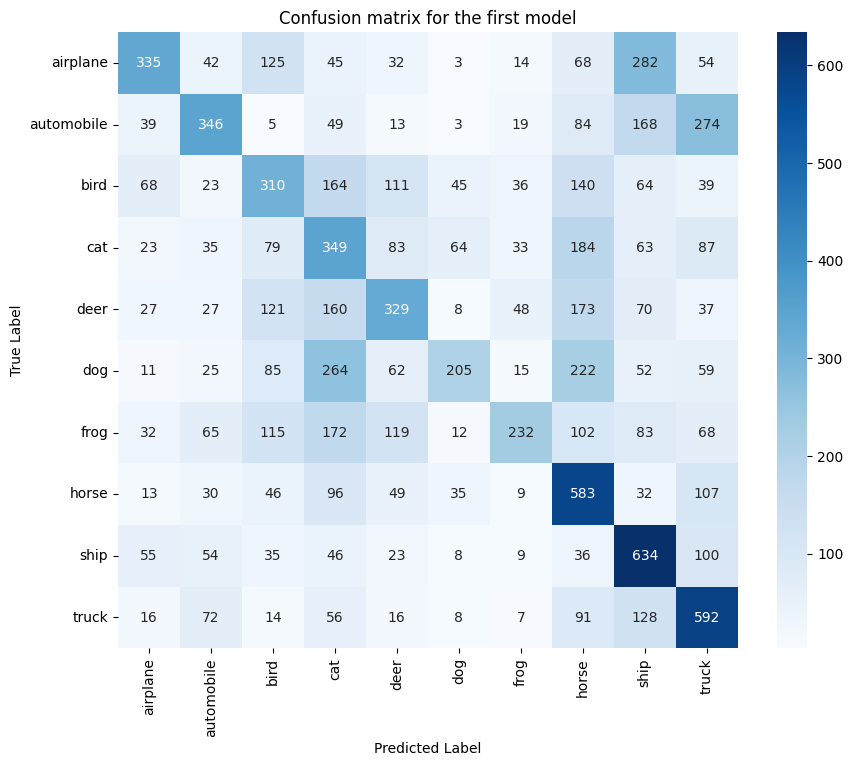

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Make predictions on the test set
y_pred_proba = model_resnet50_cifar10.predict(X_test)
y_pred_labels = np.argmax(y_pred_proba, axis=1)
y_true_labels = np.argmax(Y_test, axis=1)

print("--- Evaluation Metrics for First Model ---")

# 1. Accuracy Score
accuracy = accuracy_score(y_true_labels, y_pred_labels)
print(f"\nOverall Accuracy: {accuracy:.4f}")

# 2. Classification Report
print("\n--- Classification Report ---")

cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(classification_report(y_true_labels, y_pred_labels, target_names=cifar10_class_names))

# 3. Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

# Visualize the confusion matrix for better understanding
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cifar10_class_names,
            yticklabels=cifar10_class_names)
plt.title('Confusion matrix for the first model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Now we use above metrics to have a more comprehensive look at our initial model

For the model accuracy, this indicates that the model correctly classifies about 39.15% of the images in the test set. While this is better than a random guess (10% for 10 classes), it's considered very low for an image classification task with a ResNet50 model, especially one pre-trained on ImageNet. This low accuracy strongly suggests that the model is underfitting the CIFAR-10 dataset.

The classification report breaks down precision, recall, and F1-score for each of the 10 CIFAR-10 classes. First, the precision values vary significantly across classes. For instance, 'airplane' has a precision of 0.54, 'automobile' has 0.48, 'dog' has 0.52, and 'frog' has 0.55. This means that when the model predicts these classes, it is relatively more accurate. However, classes like 'cat' (0.25) and 'bird' (0.33) have very low precision, indicating a high rate of false positives – the model often incorrectly labels other objects as 'cat' or 'bird'. Similar to precision, recall also shows wide variation. 'Ship' (0.63) and 'truck' (0.59) have relatively high recall, meaning the model identifies a good portion of actual 'ship' and 'truck' instances. Conversely, 'dog' (0.20), 'frog' (0.23), and 'airplane' (0.34) have very low recall, suggesting the model frequently misses actual instances of these classes.

The confusion matrix (visualized with the heatmap) provides the most detailed view of the model's misclassifications. The numbers on the main diagonal represent correctly classified instances (True Positives) for each class. These values are generally low, reinforcing the low recall for most classes. The off-diagonal entries highlight classes that are frequently confused with each other. For example, 'Airplane' (actual) is often misclassified as 'ship' (282 instances) and 'bird' (125 instances); 'Dog' (actual) is frequently confused with 'cat' (264 instances) and 'horse' (222 instances).

This comprehensive view helps us diagnose the model's fundamental weakness – its inability to generalize effectively to the CIFAR-10 patterns, likely due to the inherent differences between ImageNet (on which ResNet50 was pre-trained) and CIFAR-10, as well as the freezing of the base model during initial training.

### 2.4 (1 point) When introducing architectural modifications such as skip connections, what problems in deep neural networks are these modifications designed to solve, and how do they conceptually change the way information flows through the model?


Architectural modifications like skip connections used in the enhanced model to address two major problems encountered in very deep networks like ResNet50.

First, it is vanishing or exploding gradients. As neural networks get deeper, the gradients can become extremely small (vanishing) or extremely large (exploding). Vanishing gradients limits the learning process of early layers, as their weights receive minimal updates, thus preventing the network from learning meaningful features. Whereas exploding gradients can lead to unstable training and divergence.
Second, it is the degradation problem, i.e., counter-intuitively, putting more layers in a deep neural network does not always lead to better performance but sometimes, it leads to higher training error. It implies that deeper networks are harder to optimize than shallower ones. Theoretically, a deep network should be at least as good as a shallow one, but in practice, the computer has a hard time figuring out how to tune all those extra layers correctly.

**How skip connections solve these problem?**

A skip connection works by adding the input of a block of layers directly to its output, thus creating an "identity shortcut". For a block of layers where the desired underlying mapping is `H(x)`, the skip connection allows the layers to learn a **residual mapping** `F(x) = H(x) - x`, rather than learning `H(x)` directly. The output of the block then becomes `F(x) + x`. By providing an alternative and direct path for the gradient to flow through, skip connections ensure that gradients can bypass layers that might be struggling to learn. If the weights in a certain block are very small (leading to vanishing gradients), the gradient can still flow back through the identity mapping (`+x`), allowing earlier layers to receive substantial updates. This thus can stabilize the gradient flow of the network. Morevoer, the identity mapping provided by the skip connection makes it much easier for the network to learn identity functions. If an additional layer (or block of layers) does not improve performance, it can simply learn to approximate an identity mapping (`F(x) = 0`), and the information flows through the shortcut path `x` without degradation. This ensures that adding more layers will not hurt training performance, and it allows the optimizer to focus on learning subtle improvements (the residuals `F(x)`) rather than trying to learn the entire `H(x)` mapping from scratch for every block. This makes training very deep networks feasible and effective.

**How information flows conceptually?**

Skip connections fundamentally change the way information flows through the model in several ways:

*   Instead of a purely sequential flow (input -> layer 1 -> layer 2 -> ... -> output), information now travels along multiple paths. A feature map can go through the complex layers, skip them entirely, or do both at the same time.

*   Earlier, simpler features are directly passed to later layers. This allows the network to reuse low-level features that might still be relevant for making predictions, rather than requiring every layer to constantly transform and potentially lose fine-grained details.

*   The model can learn very deep, complex hierarchical representations while ensuring that essential information from previous stages is preserved. It is like having a 'memory' or 'copy-paste' mechanism that prevents information from being entirely lost or overly transformed at each step.

### 2.5 (1 point) From a broader perspective, what lessons can be learned from this assignment about the iterative nature of deep learning model development? Discuss why building an effective model typically requires repeated cycles of data preparation, model design, training, evaluation, and refinement rather than a single linear process.

This assignment vividly illustrates that deep learning model development is inherently an iterative and cyclical process but not a straightforward linear progression. Building an effective model, especially for complex tasks, rarely succeeds in a single attempt. Instead, it needs repeated cycles of data preparation, model design, training, evaluation, and refinement.
First, it is about data preparation. Initial data loading and preprocessing are just the beginning. During evaluation, we might discover biases, inconsistencies, or insufficient diversity in the data. For instance, in this assignment, the initial use of 32x32 CIFAR-10 images directly with a ResNet50 designed for 224x224 images highlighted the need for input upsampling. This is a data preparation step driven by model performance issues. Similarly, the lack of data augmentation in the base model might contribute to poor performance, and after training the first time we have added.

Second, choosing architecture (like ResNet50) is an initial hypothesis about what might work. The baseline model demonstrated that a 'frozen' ResNet50, while powerful, wasn't suitable for small CIFAR-10 images without modification. This led to architectural modifications such as adding skip connections from intermediate layers and designing a more robust classification head. Each modification is a new design hypothesis that needs to be tested again and again until reaching expected result.

Third, training process itself is about observing how the model learns and improve the training strategies. For example, after observing training behavior in the first version, we attempt to use two-phase training in the enhanced model to impove accuracy and loss. Also, the choice of optimizer, learning rate, batch size, and epochs are all hyperparameters that often require experimentation over multiple training cycles.

Fourth, about the data, it is messy. It's rare to have a perfectly clean, balanced, and representative dataset from the beginning. Then if we encoutered the issues, we might need to recollect the data (which is actually not aplied in our model).

Finally, we might need to train, observe, enhance and repeat this cycle because Deep learning is said to be a black box. Indeed, while we understand the components of deep neural networks, it is very difficult to exactly predict their exact learning behavior and optimal configuration for a given task. Thus, this needs experimentation. Also, there's no one-size-fits-all architecture or training strategy. What works for ImageNet might fail for CIFAR-10 due to differences in image resolution, object scale, and texture. Each problem requires different solutions.

In turn, this assignment per se illustrate the idea that deep learning is a journey of continuous experimentation, learning from failures, as much an art as it is a science. Indeed, the second version of the model in this assignment is a direct outcome of such an iterative process (second version yet not second iteration) where insights from the first model's shortcomings guided significant improvements.